In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/python project/Global COVID-19 Dataset.csv"

In [10]:
df = pd.read_csv(file_path, encoding='latin1')

print(df.head())

   S. No.            Country Name      Cases    Deaths  Recovered
0     1.0                    Peru  4524748.0  220831.0  4303917.0
1     2.0                Bulgaria  1329266.0   38700.0  1290566.0
2     3.0  Bosnia and Herzegovina   403638.0   16388.0   387250.0
3     4.0                 Hungary  2230381.0   49051.0  2181330.0
4     5.0         North Macedonia   350589.0    9977.0   340612.0


In [11]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)
df

Shape: (238, 5)

Column Names:
Index(['S. No.', 'Country Name', 'Cases', 'Deaths', 'Recovered'], dtype='object')


,S. No.,Country Name,Cases,Deaths,Recovered
0,1.0,Peru,4524748.0,220831.0,4303917.0
1,2.0,Bulgaria,1329266.0,38700.0,1290566.0
2,3.0,Bosnia and Herzegovina,403638.0,16388.0,387250.0
3,4.0,Hungary,2230381.0,49051.0,2181330.0
4,5.0,North Macedonia,350589.0,9977.0,340612.0
...,...,...,...,...,...
233,NaN,NaN,NaN,NaN,NaN
234,NaN,NaN,NaN,NaN,NaN
235,NaN,NaN,NaN,NaN,NaN
236,NaN,NaN,NaN,NaN,NaN


In [12]:
cols_to_drop = [
    'Province/State',
    'Lat',
    'Long',
    'Last Update',
    'Incident Rate',
    'Case Fatality Ratio'
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Updated Columns:", df.columns)
df

Updated Columns: Index(['S. No.', 'Country Name', 'Cases', 'Deaths', 'Recovered'], dtype='object')


,S. No.,Country Name,Cases,Deaths,Recovered
0,1.0,Peru,4524748.0,220831.0,4303917.0
1,2.0,Bulgaria,1329266.0,38700.0,1290566.0
2,3.0,Bosnia and Herzegovina,403638.0,16388.0,387250.0
3,4.0,Hungary,2230381.0,49051.0,2181330.0
4,5.0,North Macedonia,350589.0,9977.0,340612.0
...,...,...,...,...,...
233,NaN,NaN,NaN,NaN,NaN
234,NaN,NaN,NaN,NaN,NaN
235,NaN,NaN,NaN,NaN,NaN
236,NaN,NaN,NaN,NaN,NaN


In [14]:


print(df.isnull().sum())
df.fillna(df.mean(numeric_only=True), inplace=True)

df = df.drop_duplicates()



S. No.          8
Country Name    8
Cases           8
Deaths          8
Recovered       8
dtype: int64


In [17]:
print("Total Confirmed Caes\n")
print(df['Cases'].sum())

Total Confirmed Caes

978146247.3391304


In [18]:
print("Total Deaths\n")
print(df['Deaths'].sum())

Total Deaths

8376619.42173913


In [19]:
print("Total Recoveries\n")
print(df['Recovered'].sum())

Total Recoveries

969769627.9173913


In [22]:
df.loc[:, 'Active'] = df['Cases'] - df['Deaths'] - df['Recovered']
print("Total Active Cases\n")
print(df['Active'].sum())

Total Active Cases

9.313225746154785e-10


In [28]:
country_comparison = df[['Country Name','Cases','Deaths','Recovered']]

country_comparison = country_comparison.sort_values(by='Cases', ascending=False)

country_comparison

,Country Name,Cases,Deaths,Recovered
30,European Union,185636059.0,1261370.0,184374689.0
16,United States,103436829.0,1186984.0,102249845.0
193,China,99354727.0,122196.0,99232531.0
152,India,45037776.0,533589.0,44504187.0
38,France,38997490.0,168091.0,38829399.0
...,...,...,...,...
120,Wallis and Futuna,3760.0,9.0,3751.0
172,Macau,3514.0,121.0,3393.0
158,Saint Pierre and Miquelon,3426.0,2.0,3424.0
192,Tuvalu,2943.0,1.0,2942.0


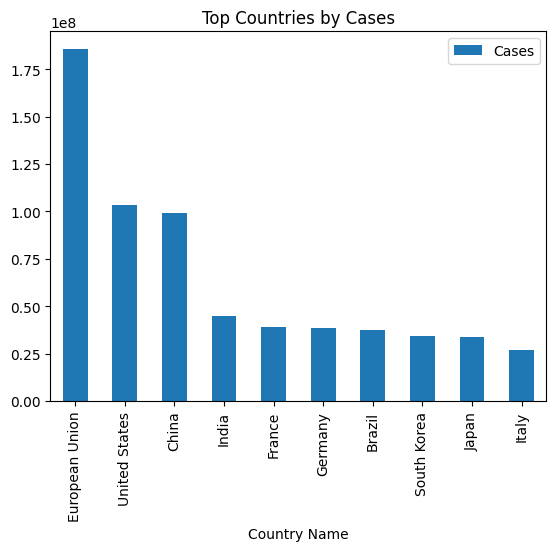

In [36]:
import matplotlib.pyplot as plt

top10 = country_comparison.head(10)
top10.plot(x='Country Name', y='Cases', kind='bar')
plt.title("Top Countries by Cases")
plt.show()

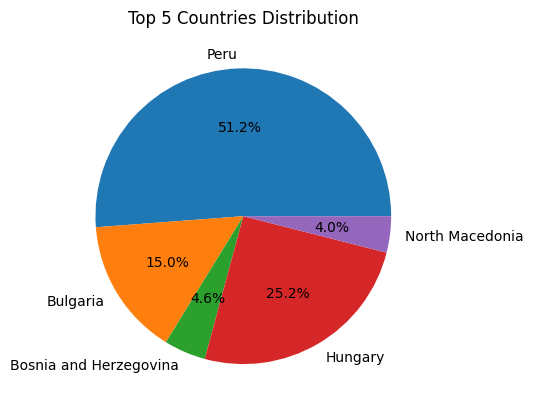

In [38]:
plt.pie(df['Cases'].head(5), labels=df['Country Name'].head(5), autopct='%1.1f%%')
plt.title("Top 5 Countries Distribution")
plt.show()

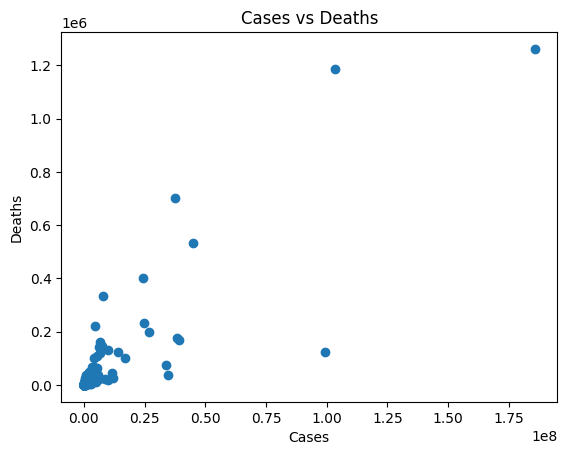

In [40]:
plt.scatter(df['Cases'], df['Deaths'])
plt.xlabel("Cases")
plt.ylabel("Deaths")
plt.title("Cases vs Deaths")
plt.show()

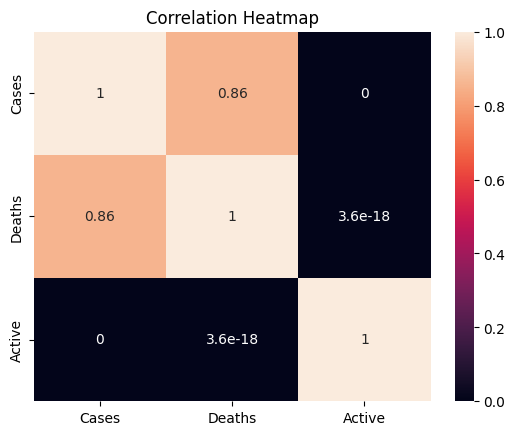

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
# The 'Active' column already exists, so this 'if' block will be skipped.
# However, if 'Active' needed to be created, it should use 'Cases' instead of 'Confirmed'.
# For clarity, I'm modifying it to use 'Cases' in case this block is ever hit.
if 'Active' not in df.columns:
    df['Active'] = df['Cases'] - df['Deaths']
corr = df[['Cases', 'Deaths', 'Active']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [44]:
!pip install dash
from dash import Dash, dcc, html, Input, Output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 55.6 MB/s eta 0:00:00
